# Notebook 06 — UI Attribute Extraction

**Goal:** Use the trained YOLOv8n model to detect UI components in RICO screenshots, visualize the detections, crop each detected component, and prepare the crops for attribute extraction.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import shutil
import zipfile

dataset_zip = "/content/drive/MyDrive/dataset.zip"
local_zip = "/content/dataset.zip"
dataset_dir = "/content/dataset"

if not os.path.exists(dataset_dir):
    if not os.path.exists(local_zip):
        shutil.copy(dataset_zip, local_zip)

    with zipfile.ZipFile(local_zip, "r") as zip_ref:
        zip_ref.extractall("/content")

print("Dataset ready:", os.path.exists(dataset_dir))

Dataset ready: True


In [ ]:
# Quick dataset check

for split in ["train", "val", "test"]:
    image_dir = f"{dataset_dir}/images/{split}"
    label_dir = f"{dataset_dir}/labels/{split}"

    image_count = len([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    label_count = len([
        f for f in os.listdir(label_dir)
        if f.lower().endswith(".txt")
    ])

    print(f"{split:5s} → images: {image_count:,} | labels: {label_count:,}")

train → images: 53,008 | labels: 53,008
val   → images: 6,626 | labels: 6,626
test  → images: 6,627 | labels: 6,627


### Load the trained YOLOv8n model

In [ ]:
!pip -q install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/YOLO_Runs/rico_yolo_v2_continue/weights/last.pt"

model = YOLO(model_path)

print("YOLOv8n model loaded successfully.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n model loaded successfully.


In [ ]:
print("Number of classes:", len(model.names))

for class_id, name in model.names.items():
    print(f"{class_id:2d}  {name}")

Number of classes: 25
 0  Button
 1  CheckBox
 2  CheckedTextView
 3  EditText
 4  ImageButton
 5  ImageView
 6  ProgressBar
 7  RadioButton
 8  RatingBar
 9  SeekBar
10  Spinner
11  Switch
12  SwitchCompat
13  TextView
14  ToggleButton
15  VideoView
16  AutoCompleteTextView
17  MultiAutoCompleteTextView
18  Chronometer
19  DigitalClock
20  AnalogClock
21  DatePicker
22  TimePicker
23  WebView
24  MapView


#### Select a validation screenshot

In [ ]:
test_image = "/content/dataset/images/val/6854.png"

print("Testing image:")
print(test_image)

Testing image:
/content/dataset/images/val/6854.png


#### Run YOLO detection

In [ ]:
results = model.predict(
    source=test_image,
    imgsz=640,
    conf=0.50,
    iou=0.45,
    verbose=False
)

result = results[0]

print("Detection completed!")
print("Number of detections:", len(result.boxes))

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(
        f"{model.names[class_id]:20s} "
        f"confidence={confidence:.3f} "
        f"box=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
    )

Detection completed!
Number of detections: 2
Button               confidence=0.941 box=(0.3, 85.4, 81.8, 280.1)
EditText             confidence=0.745 box=(0.0, 83.4, 81.4, 279.4)


#### Visualize YOLO detections

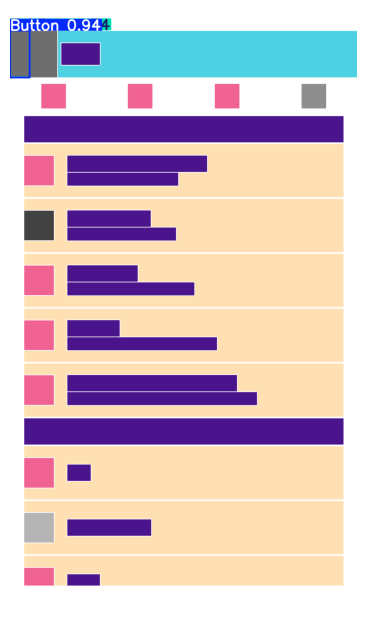

In [ ]:
import matplotlib.pyplot as plt

annotated = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

####  Crop detected UI components

In [ ]:
import cv2
import os
import shutil

crop_dir = "/content/component_crops"

# Start fresh so crops from previous test images are not mixed in.
if os.path.exists(crop_dir):
    shutil.rmtree(crop_dir)

os.makedirs(crop_dir)

image = cv2.imread(test_image)
h, w = image.shape[:2]

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    # Keep coordinates inside the image.
    x1 = max(0, min(x1, w))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h))
    y2 = max(0, min(y2, h))

    # Skip invalid boxes.
    if x2 <= x1 or y2 <= y1:
        continue

    crop = image[y1:y2, x1:x2]
    class_name = model.names[class_id]

    filename = f"{i:03d}_{class_name}_{confidence:.3f}.png"
    save_path = os.path.join(crop_dir, filename)

    cv2.imwrite(save_path, crop)

    print(
        f"Saved: {filename} | "
        f"size={x2-x1} x {y2-y1}"
    )

print("\nCrops saved to:", crop_dir)

Saved: 000_Button_0.941.png | size=81 x 195
Saved: 001_EditText_0.745.png | size=81 x 196

Crops saved to: /content/component_crops


#### View the extracted component crops

Number of crops: 2


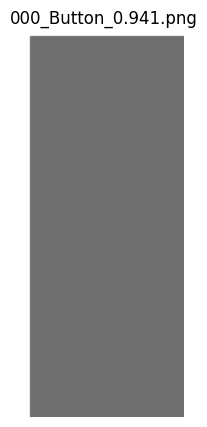

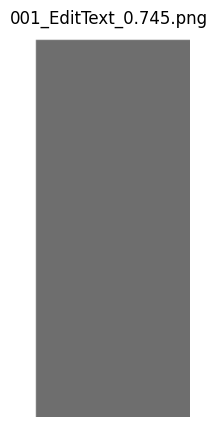

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

crop_files = sorted(os.listdir(crop_dir))

print("Number of crops:", len(crop_files))

for filename in crop_files:
    path = os.path.join(crop_dir, filename)

    img = Image.open(path)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")
    plt.show()

## Next step — Attribute Extraction

The YOLO detections and component crops are now ready.

Next we will extract structured attributes such as:

- bounding-box position
- width and height
- area
- aspect ratio
- dominant color
- brightness
- text presence / OCR
- other component-specific visual attributes

The extracted attributes will eventually be stored as structured data for downstream analysis.

In [ ]:
import cv2
import pandas as pd

# Read original screenshot
image = cv2.imread(test_image)
image_height, image_width = image.shape[:2]

geometric_attributes = []

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # YOLO bounding box
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    # Dimensions
    width = x2 - x1
    height = y2 - y1

    # Area
    area = width * height

    # Center
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    # Aspect ratio
    aspect_ratio = width / height if height > 0 else 0

    # Normalized values
    normalized_x = center_x / image_width
    normalized_y = center_y / image_height
    normalized_width = width / image_width
    normalized_height = height / image_height

    geometric_attributes.append({
        "component_id": i,
        "class_id": class_id,
        "component": model.names[class_id],
        "confidence": confidence,

        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,

        "width": width,
        "height": height,
        "area": area,
        "aspect_ratio": aspect_ratio,

        "center_x": center_x,
        "center_y": center_y,

        "normalized_x": normalized_x,
        "normalized_y": normalized_y,
        "normalized_width": normalized_width,
        "normalized_height": normalized_height
    })

geometry_df = pd.DataFrame(geometric_attributes)

geometry_df

,component_id,class_id,component,confidence,x1,y1,x2,y2,width,height,area,aspect_ratio,center_x,center_y,normalized_x,normalized_y,normalized_width,normalized_height
0,0,0,Button,0.941145,0.298187,85.442375,81.786545,280.117676,81.488358,194.675301,15863.77050,0.418586,41.042366,182.780025,0.028502,0.071398,0.056589,0.076045
1,1,3,EditText,0.744870,0.000000,83.400841,81.411301,279.435822,81.411301,196.034981,15959.46276,0.415290,40.705650,181.418331,0.028268,0.070867,0.056536,0.076576


In [ ]:
print("Number of components:", len(geometry_df))
print("Image dimensions:", image_width, "x", image_height)

geometry_df[
    [
        "component",
        "confidence",
        "width",
        "height",
        "area",
        "aspect_ratio",
        "normalized_x",
        "normalized_y",
        "normalized_width",
        "normalized_height"
    ]
]

Number of components: 2
Image dimensions: 1440 x 2560


,component,confidence,width,height,area,aspect_ratio,normalized_x,normalized_y,normalized_width,normalized_height
0,Button,0.941145,81.488358,194.675301,15863.77050,0.418586,0.028502,0.071398,0.056589,0.076045
1,EditText,0.744870,81.411301,196.034981,15959.46276,0.415290,0.028268,0.070867,0.056536,0.076576


In [ ]:
import cv2
import numpy as np

visual_attributes = []

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    crop = image[y1:y2, x1:x2]

    # Convert BGR → RGB
    rgb_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # Average RGB color
    mean_color = rgb_crop.mean(axis=(0, 1))

    # Brightness
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())

    visual_attributes.append({
        "component_id": i,
        "mean_red": float(mean_color[0]),
        "mean_green": float(mean_color[1]),
        "mean_blue": float(mean_color[2]),
        "brightness": brightness
    })

visual_df = pd.DataFrame(visual_attributes)

visual_df

,component_id,mean_red,mean_green,mean_blue,brightness
0,0,116.802469,116.802469,116.802469,116.802469
1,1,118.219955,118.219955,118.219955,118.219955


In [ ]:
import cv2
import numpy as np
import pandas as pd

visual_attributes = []

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    crop = image[y1:y2, x1:x2]

    # Convert to grayscale
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # Brightness
    brightness = float(np.mean(gray))

    # Contrast = standard deviation of pixel intensity
    contrast = float(np.std(gray))

    # Minimum and maximum intensity
    min_intensity = int(np.min(gray))
    max_intensity = int(np.max(gray))

    visual_attributes.append({
        "component_id": i,
        "brightness": brightness,
        "contrast": contrast,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity
    })

visual_df = pd.DataFrame(visual_attributes)

visual_df

,component_id,brightness,contrast,min_intensity,max_intensity
0,0,116.802469,30.660796,110,255
1,1,118.219955,33.530967,110,255


In [ ]:
!pip -q install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 30.2 MB/s eta 0:00:00


In [ ]:
import easyocr
import cv2
import pandas as pd

reader = easyocr.Reader(['en'], gpu=True)

text_attributes = []

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    crop = image[y1:y2, x1:x2]

    # OCR
    ocr_results = reader.readtext(crop)

    detected_text = " ".join(
        [text for (_, text, conf) in ocr_results if conf >= 0.30]
    )

    text_attributes.append({
        "component_id": i,
        "detected_text": detected_text,
        "has_text": len(detected_text.strip()) > 0,
        "text_count": len(ocr_results)
    })

text_df = pd.DataFrame(text_attributes)

text_df

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

,component_id,detected_text,has_text,text_count
0,0,,False,0
1,1,,False,0


In [ ]:
structured_df = (
    geometry_df
    .merge(visual_df, on="component_id", how="left")
    .merge(text_df, on="component_id", how="left")
)

structured_df

,component_id,class_id,component,confidence,x1,y1,x2,y2,width,height,...,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,detected_text,has_text,text_count
0,0,0,Button,0.941145,0.298187,85.442375,81.786545,280.117676,81.488358,194.675301,...,0.071398,0.056589,0.076045,116.802469,30.660796,110,255,,False,0
1,1,3,EditText,0.744870,0.000000,83.400841,81.411301,279.435822,81.411301,196.034981,...,0.070867,0.056536,0.076576,118.219955,33.530967,110,255,,False,0


In [ ]:
print("Rows:", len(structured_df))
print("Columns:", len(structured_df.columns))

print("\nColumns:")
for col in structured_df.columns:
    print("-", col)

Rows: 2
Columns: 25

Columns:
- component_id
- class_id
- component
- confidence
- x1
- y1
- x2
- y2
- width
- height
- area
- aspect_ratio
- center_x
- center_y
- normalized_x
- normalized_y
- normalized_width
- normalized_height
- brightness
- contrast
- min_intensity
- max_intensity
- detected_text
- has_text
- text_count


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# Use a subset first so we can verify everything works
image_dir = "/content/dataset/images/val"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

# Start with 100 images
image_files = sorted(image_files)[:100]

all_components = []

for image_index, filename in enumerate(image_files):

    image_path = os.path.join(image_dir, filename)

    image = cv2.imread(image_path)

    if image is None:
        continue

    image_height, image_width = image.shape[:2]

    # YOLO inference
    result = model(image_path, verbose=False)[0]

    for component_id, box in enumerate(result.boxes):

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        # Geometry
        width = x2 - x1
        height = y2 - y1
        area = width * height

        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        aspect_ratio = width / height if height > 0 else 0

        normalized_x = center_x / image_width
        normalized_y = center_y / image_height
        normalized_width = width / image_width
        normalized_height = height / image_height

        # Crop
        x1_i, y1_i, x2_i, y2_i = map(
            int, [x1, y1, x2, y2]
        )

        crop = image[y1_i:y2_i, x1_i:x2_i]

        if crop.size == 0:
            continue

        # Visual attributes
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

        brightness = float(np.mean(gray))
        contrast = float(np.std(gray))
        min_intensity = int(np.min(gray))
        max_intensity = int(np.max(gray))

        all_components.append({
            "image": filename,
            "component_id": component_id,

            "class_id": class_id,
            "component": model.names[class_id],
            "confidence": confidence,

            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,

            "width": width,
            "height": height,
            "area": area,
            "aspect_ratio": aspect_ratio,

            "center_x": center_x,
            "center_y": center_y,

            "normalized_x": normalized_x,
            "normalized_y": normalized_y,
            "normalized_width": normalized_width,
            "normalized_height": normalized_height,

            "brightness": brightness,
            "contrast": contrast,
            "min_intensity": min_intensity,
            "max_intensity": max_intensity
        })

    if (image_index + 1) % 10 == 0:
        print(
            f"Processed {image_index + 1}/{len(image_files)} images"
        )

batch_geometry_visual_df = pd.DataFrame(all_components)

print("\nFinished!")
print("Images processed:", len(image_files))
print("Components detected:", len(batch_geometry_visual_df))

batch_geometry_visual_df.head()

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images

Finished!
Images processed: 100
Components detected: 155


,image,component_id,class_id,component,confidence,x1,y1,x2,y2,width,...,center_x,center_y,normalized_x,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity
0,10002.png,0,2,CheckedTextView,0.502286,0.821686,82.077820,84.756989,284.991638,83.935303,...,42.789337,183.534729,0.029715,0.071693,0.058288,0.079263,179.031471,44.581621,50,255
1,10010.png,0,2,CheckedTextView,0.630227,0.432907,83.921669,83.684662,280.505280,83.251755,...,42.058784,182.213474,0.029207,0.071177,0.057814,0.076790,158.619350,33.390921,146,255
2,10010.png,1,2,CheckedTextView,0.427453,23.193726,80.703644,1363.871338,285.599701,1340.677612,...,693.532532,183.151672,0.481620,0.071544,0.931026,0.080038,186.758748,39.678008,146,255
3,10010.png,2,3,EditText,0.278310,0.000000,80.900490,82.139648,278.541290,82.139648,...,41.069824,179.720890,0.028521,0.070203,0.057041,0.077203,159.714400,35.140015,146,255
4,10031.png,0,2,CheckedTextView,0.597760,1.192478,86.552521,83.562469,278.167755,82.369991,...,42.377474,182.360138,0.029429,0.071234,0.057201,0.074850,89.039634,28.920227,84,255


In [ ]:
# Run OCR on the 155 detected components

ocr_attributes = []

for idx, row in batch_geometry_visual_df.iterrows():

    image_path = os.path.join(image_dir, row["image"])

    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not read: {row['image']}")
        continue

    # Original bounding box
    x1 = max(0, int(row["x1"]))
    y1 = max(0, int(row["y1"]))
    x2 = min(image.shape[1], int(row["x2"]))
    y2 = min(image.shape[0], int(row["y2"]))

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        ocr_attributes.append({
            "image": row["image"],
            "component_id": row["component_id"],
            "detected_text": "",
            "has_text": False,
            "text_count": 0
        })
        continue

    # OCR
    ocr_results = reader.readtext(crop)

    # Keep reasonably confident OCR results
    valid_text = [
        text.strip()
        for (_, text, conf) in ocr_results
        if conf >= 0.30 and text.strip()
    ]

    detected_text = " ".join(valid_text)

    ocr_attributes.append({
        "image": row["image"],
        "component_id": row["component_id"],
        "detected_text": detected_text,
        "has_text": len(valid_text) > 0,
        "text_count": len(valid_text)
    })

    if (idx + 1) % 25 == 0:
        print(f"OCR processed: {idx + 1}/{len(batch_geometry_visual_df)}")


ocr_df = pd.DataFrame(ocr_attributes)

print("\nOCR finished!")
print("OCR records:", len(ocr_df))

ocr_df.head(20)

OCR processed: 25/155
OCR processed: 50/155
OCR processed: 75/155
OCR processed: 100/155
OCR processed: 125/155
OCR processed: 150/155

OCR finished!
OCR records: 155


,image,component_id,detected_text,has_text,text_count
0,10002.png,0,,False,0
1,10010.png,0,,False,0
2,10010.png,1,,False,0
3,10010.png,2,,False,0
4,10031.png,0,,False,0
5,10042.png,0,,False,0
6,10050.png,0,,False,0
7,10050.png,1,,False,0
8,10051.png,0,,False,0
9,10051.png,1,,False,0


In [ ]:
print("Components with text:",
      ocr_df["has_text"].sum())

print("Components without text:",
      (~ocr_df["has_text"]).sum())

print("\nOCR results:")
display(
    ocr_df[
        ocr_df["has_text"] == True
    ][
        ["image", "component_id", "detected_text", "text_count"]
    ].head(20)
)

Components with text: 1
Components without text: 154

OCR results:


,image,component_id,detected_text,text_count
23,10123.png,1,L,1


In [ ]:
ocr_df["text_count"].value_counts().sort_index()

,count
text_count,
0,154
1,1


In [ ]:
structured_component_df = (
    batch_geometry_visual_df
    .merge(
        ocr_df,
        on=["image", "component_id"],
        how="left"
    )
)

print("Rows:", len(structured_component_df))
print("Columns:", len(structured_component_df.columns))

structured_component_df.head()

Rows: 155
Columns: 26


,image,component_id,class_id,component,confidence,x1,y1,x2,y2,width,...,normalized_y,normalized_width,normalized_height,brightness,contrast,min_intensity,max_intensity,detected_text,has_text,text_count
0,10002.png,0,2,CheckedTextView,0.502286,0.821686,82.077820,84.756989,284.991638,83.935303,...,0.071693,0.058288,0.079263,179.031471,44.581621,50,255,,False,0
1,10010.png,0,2,CheckedTextView,0.630227,0.432907,83.921669,83.684662,280.505280,83.251755,...,0.071177,0.057814,0.076790,158.619350,33.390921,146,255,,False,0
2,10010.png,1,2,CheckedTextView,0.427453,23.193726,80.703644,1363.871338,285.599701,1340.677612,...,0.071544,0.931026,0.080038,186.758748,39.678008,146,255,,False,0
3,10010.png,2,3,EditText,0.278310,0.000000,80.900490,82.139648,278.541290,82.139648,...,0.070203,0.057041,0.077203,159.714400,35.140015,146,255,,False,0
4,10031.png,0,2,CheckedTextView,0.597760,1.192478,86.552521,83.562469,278.167755,82.369991,...,0.071234,0.057201,0.074850,89.039634,28.920227,84,255,,False,0


In [ ]:
structured_component_df[
    [
        "image",
        "component",
        "confidence",
        "width",
        "height",
        "aspect_ratio",
        "brightness",
        "contrast",
        "detected_text",
        "has_text"
    ]
]

,image,component,confidence,width,height,aspect_ratio,brightness,contrast,detected_text,has_text
0,10002.png,CheckedTextView,0.502286,83.935303,202.913818,0.413650,179.031471,44.581621,,False
1,10010.png,CheckedTextView,0.630227,83.251755,196.583611,0.423493,158.619350,33.390921,,False
2,10010.png,CheckedTextView,0.427453,1340.677612,204.896057,6.543208,186.758748,39.678008,,False
3,10010.png,EditText,0.278310,82.139648,197.640800,0.415601,159.714400,35.140015,,False
4,10031.png,CheckedTextView,0.597760,82.369991,191.615234,0.429872,89.039634,28.920227,,False
...,...,...,...,...,...,...,...,...,...,...
150,10969.png,CheckedTextView,0.255655,967.941772,193.827057,4.993842,109.888207,67.305108,,False
151,10987.png,Button,0.930328,81.575058,194.102539,0.420268,116.745034,30.537427,,False
152,10987.png,EditText,0.658431,81.232025,196.906189,0.412542,118.205490,33.503223,,False
153,11000.png,CheckedTextView,0.593670,403.261841,200.915314,2.007123,178.470668,49.849359,,False


In [ ]:
output_path = "/content/structured_component_dataset_v1.csv"

structured_component_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: /content/structured_component_dataset_v1.csv


In [ ]:
import os

print(
    "File exists:",
    os.path.exists(output_path)
)

print(
    "File size:",
    round(os.path.getsize(output_path) / 1024, 2),
    "KB"
)

File exists: True
File size: 54.12 KB


In [ ]:
import pandas as pd
import os


structured_df = pd.read_csv(output_path)

print("Dataset shape:", structured_df.shape)
print("\nColumns:")
print(structured_df.columns.tolist())

print("\nMissing values:")
print(structured_df.isnull().sum())

print("\nDuplicate rows:")
print(structured_df.duplicated().sum())

print("\nComponent distribution:")
print(structured_df["component"].value_counts())

print("\nConfidence statistics:")
print(structured_df["confidence"].describe())

Dataset shape: (155, 26)

Columns:
['image', 'component_id', 'class_id', 'component', 'confidence', 'x1', 'y1', 'x2', 'y2', 'width', 'height', 'area', 'aspect_ratio', 'center_x', 'center_y', 'normalized_x', 'normalized_y', 'normalized_width', 'normalized_height', 'brightness', 'contrast', 'min_intensity', 'max_intensity', 'detected_text', 'has_text', 'text_count']

Missing values:
image                  0
component_id           0
class_id               0
component              0
confidence             0
x1                     0
y1                     0
x2                     0
y2                     0
width                  0
height                 0
area                   0
aspect_ratio           0
center_x               0
center_y               0
normalized_x           0
normalized_y           0
normalized_width       0
normalized_height      0
brightness             0
contrast               0
min_intensity          0
max_intensity          0
detected_text        154
has_text        

In [ ]:
# Clean OCR text field
structured_df["detected_text"] = structured_df["detected_text"].fillna("")

# Make sure text-related fields are consistent
structured_df["has_text"] = structured_df["detected_text"].str.strip().ne("")
structured_df["text_count"] = structured_df["detected_text"].apply(
    lambda x: len(x.split()) if x.strip() else 0
)

print("Missing values after cleaning:")
print(structured_df.isna().sum())

Missing values after cleaning:
image                0
component_id         0
class_id             0
component            0
confidence           0
x1                   0
y1                   0
x2                   0
y2                   0
width                0
height               0
area                 0
aspect_ratio         0
center_x             0
center_y             0
normalized_x         0
normalized_y         0
normalized_width     0
normalized_height    0
brightness           0
contrast             0
min_intensity        0
max_intensity        0
detected_text        0
has_text             0
text_count           0
dtype: int64


In [ ]:
print("Text-bearing components:")
print(structured_df["has_text"].value_counts())

print("\nComponents with detected text:")
display(
    structured_df[structured_df["has_text"]][
        ["image", "component", "confidence", "detected_text", "text_count"]
    ]
)

Text-bearing components:
has_text
False    154
True       1
Name: count, dtype: int64

Components with detected text:


,image,component,confidence,detected_text,text_count
23,10123.png,CheckedTextView,0.892235,L,1


In [ ]:
print("Coordinate / geometry checks")

print("Invalid width:", (structured_df["width"] <= 0).sum())
print("Invalid height:", (structured_df["height"] <= 0).sum())
print("Invalid area:", (structured_df["area"] <= 0).sum())
print("Invalid aspect ratio:", (structured_df["aspect_ratio"] <= 0).sum())

print("\nNormalized coordinate ranges:")
for col in [
    "normalized_x",
    "normalized_y",
    "normalized_width",
    "normalized_height"
]:
    print(
        f"{col}:",
        structured_df[col].min(),
        "→",
        structured_df[col].max()
    )

Coordinate / geometry checks
Invalid width: 0
Invalid height: 0
Invalid area: 0
Invalid aspect ratio: 0

Normalized coordinate ranges:
normalized_x: 0.0280903922186957 → 0.5740765041775173
normalized_y: 0.0349655300378799 → 0.0736531615257263
normalized_width: 0.0389026429918077 → 0.931026119656033
normalized_height: 0.0699248254299163 → 0.0916370928287506


In [ ]:
print("Dataset shape:", structured_df.shape)
print("Duplicate rows:", structured_df.duplicated().sum())

print("\nComponent distribution:")
print(structured_df["component"].value_counts())

print("\nConfidence:")
print(structured_df["confidence"].describe())

Dataset shape: (155, 26)
Duplicate rows: 0

Component distribution:
component
CheckedTextView    71
Button             41
EditText           38
CheckBox            5
Name: count, dtype: int64

Confidence:
count    155.000000
mean       0.609934
std        0.232735
min        0.250661
25%        0.420586
50%        0.579331
75%        0.877091
max        0.968276
Name: confidence, dtype: float64
